# 20 Modal identification

In [ ]:
# !pip install pyFBS

['Requirement already satisfied: pyFBS in c:\\users\\marko\\programming\\.conda\\lib\\site-packages (0.3.1)',
 'Requirement already satisfied: ansys-mapdl-reader in c:\\users\\marko\\programming\\.conda\\lib\\site-packages (from pyFBS) (0.54.2)',
 'Requirement already satisfied: pyuff in c:\\users\\marko\\programming\\.conda\\lib\\site-packages (from pyFBS) (2.4.6)',
 'Requirement already satisfied: pyvista in c:\\users\\marko\\programming\\.conda\\lib\\site-packages (from pyFBS) (0.44.2)',
 'Requirement already satisfied: pyvistaqt in c:\\users\\marko\\programming\\.conda\\lib\\site-packages (from pyFBS) (0.11.2)',
 'Requirement already satisfied: pandas<2 in c:\\users\\marko\\programming\\.conda\\lib\\site-packages (from pyFBS) (1.5.3)',
 'Requirement already satisfied: scipy in c:\\users\\marko\\programming\\.conda\\lib\\site-packages (from pyFBS) (1.15.2)',
 'Requirement already satisfied: tqdm in c:\\users\\marko\\programming\\.conda\\lib\\site-packages (from pyFBS) (4.67.1)',
 'R

In [9]:
import pyFBS
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

## Data import

Importing of example data: 
 - experimentally obtained FRFs stored in a pickle file

In [ ]:
# pyFBS.download_lab_testbench()

100%|██████████| 10/10 [00:26<00:00,  2.60s/it]


100%|██████████| 3/3 [00:01<00:00,  1.97it/s]


100%|██████████| 10/10 [00:18<00:00,  1.86s/it]


In [ ]:
exp_file = r"./lab_testbench/Measurements/Y_A.p"

### Experimental data import

In [ ]:
freq, Y_AB_exp = np.load(exp_file, allow_pickle = True)
Y_AB_exp = np.transpose(Y_AB_exp, (2, 0, 1))

### Class initalization

In [ ]:
_id = pyFBS.modal_id(freq,Y_AB_exp)

### LSCF

In [ ]:
_id.pLSCF(max_order=30)

Order:30/30


### Stability chart

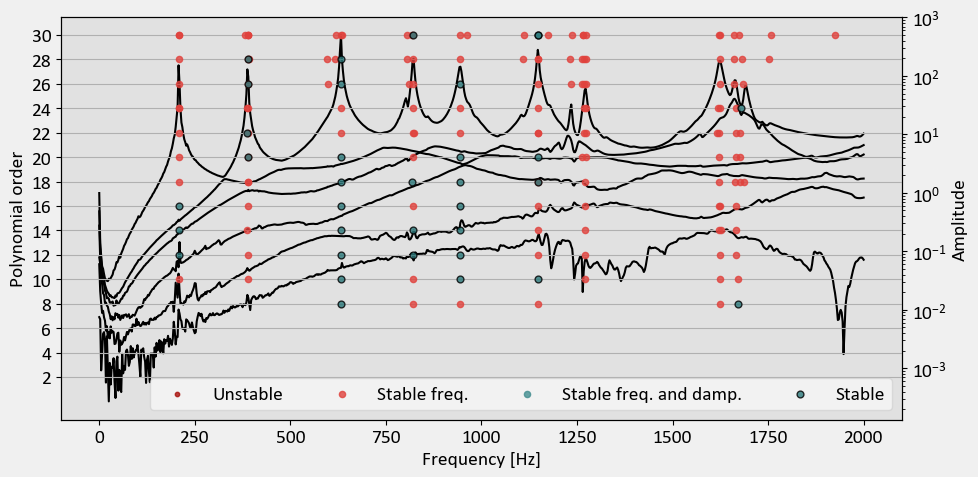

In [ ]:
_id.stabilization()

In [ ]:
# for automated testing purposes
_id.win.selected_ind = [185, 187]
_id.win.get_modal_data()

### LSFD

In [ ]:
_id.pLSFD(lower_residuals=False)

### FRF display

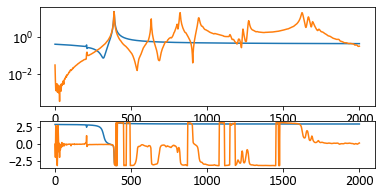

In [ ]:
o = 1
i = 1

# %matplotlib inline
plt.subplot(211)
plt.semilogy(freq, np.abs(_id.FRF_rec[:,o,i]))
plt.semilogy(freq, np.abs(Y_AB_exp[:,o,i]));

plt.subplot(413)
plt.plot(freq, np.angle(_id.FRF_rec[:,o,i]))
plt.plot(freq, np.angle(Y_AB_exp[:,o,i]));
plt.show()